In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

In [2]:
# test on a single single choice

In [5]:
doors = [1,0,0]
random.seed(time.time())
d0 = int((random.random())*(3))

random.seed(time.time())
dgoat = int(random.random()*2+1)
while dgoat==d0: 
    dgoat = int(random.random()*2+1)

remaining_doors =[]
x = 99 #i name the excluded door to distinguish it from the two still viable doors
for i in range(len(doors)):
    if i!=dgoat: 
        remaining_doors.append(doors[i])
    else: remaining_doors.append(x)
print(remaining_doors)

result_conservative = d0

initial_guess = d0

i = d0
while ((i==d0) or (i==dgoat)):
    i = int(random.random()*3)
dswitcher = i
result_switcher = remaining_doors[dswitcher]

dnewcomer = int(random.random()*3)
while dnewcomer == remaining_doors.index(x):
    dnewcomer = int(random.random()*3)
result_newcomer = remaining_doors[dnewcomer]

[1, 99, 0]


In [4]:
#prior choices!!!

In [ ]:
#TOY EXPERIMENT

In [6]:
N = 10000
doors = [1,0,0]

conservative_tally = 0
switcher_tally = 0
newcomer_tally = 0

for i in range(N):
    #player selects a door
    random.seed(time.time())
    d0 = int((random.random())*(3))
    
    #presenter selects a door
    dgoat = int(random.random()*2+1)
    while dgoat==d0: 
        dgoat = int(random.random()*2+1)

    #remaining doors
    remaining_doors =[]
    x=99
    for i in range(len(doors)):
        if i!=dgoat: 
            remaining_doors.append(doors[i])
        else: remaining_doors.append(x)
    
    #conservative conserves
    result_conservative = doors[d0]
    conservative_tally+=result_conservative

    #switcher switches
    i = d0
    while (i==d0 or i==dgoat):
        i = int(random.random()*3)
    dswitcher = i
    result_switcher = remaining_doors[dswitcher]
    switcher_tally+=result_switcher

    #newcomer chooses
    dnewcomer = int(random.random()*3)
    while dnewcomer == remaining_doors.index(x):
        dnewcomer = int(random.random()*3)
    result_newcomer = remaining_doors[dnewcomer]
    newcomer_tally+=result_newcomer

In [7]:
print('conservative: %.4f' % (conservative_tally/N))
print('switcher: %.4f' % (switcher_tally/N))
print('newcomer: %.4f' % (newcomer_tally/N))

conservative: 0.3451
switcher: 0.6549
newcomer: 0.5002


In [8]:
doors = [1,0,0]

conservative_tallies = []
switcher_tallies = []
newcomer_tallies = []

arr_n = np.logspace(2,5.5,20)
arr_n = np.array([int(i) for i in arr_n])


for N in arr_n: 
    conservative_tally = 0
    switcher_tally = 0
    newcomer_tally = 0
    for i in range(N):
        #player selects a door
        random.seed(time.time())
        d0 = int((random.random())*(3))
        
        #presenter selects a door
        dgoat = int(random.random()*2+1)
        while dgoat==d0: 
            dgoat = int(random.random()*2+1)
    
        #remaining doors
        remaining_doors =[]
        x=99
        for i in range(len(doors)):
            if i!=dgoat: 
                remaining_doors.append(doors[i])
            else: remaining_doors.append(x)
        
        #conservative conserves
        result_conservative = doors[d0]
        conservative_tally+=result_conservative
    
        #switcher switches
        i = d0
        while (i==d0 or i==dgoat):
            i = int(random.random()*3)
        dswitcher = i
        result_switcher = remaining_doors[dswitcher]
        switcher_tally+=result_switcher
    
        #newcomer chooses
        dnewcomer = int(random.random()*3)
        while dnewcomer == remaining_doors.index(x):
            dnewcomer = int(random.random()*3)
        result_newcomer = remaining_doors[dnewcomer]
        newcomer_tally+=result_newcomer

        
    conservative_tallies.append(conservative_tally/N)
    switcher_tallies.append(switcher_tally/N)
    newcomer_tallies.append(newcomer_tally/N)
    

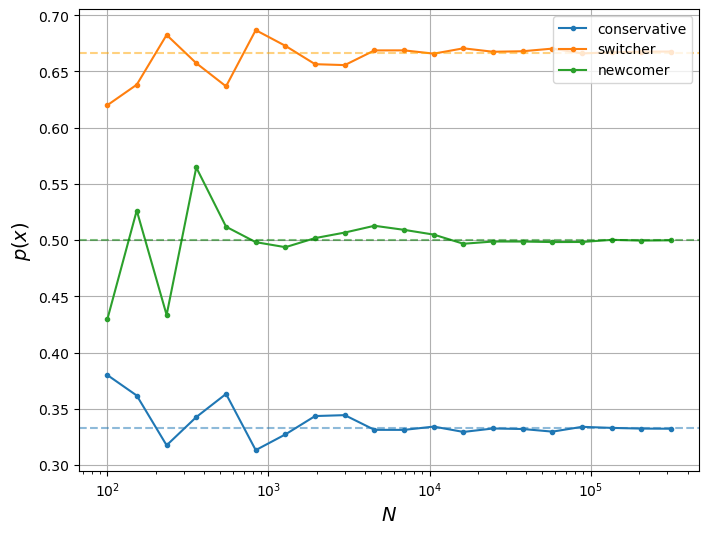

In [9]:
fig,ax = plt.subplots(figsize=(8, 6))

plt.plot(arr_n, conservative_tallies,marker='.',label='conservative')
plt.plot(arr_n, switcher_tallies,marker='.',label='switcher')
plt.plot(arr_n, newcomer_tallies,marker='.',label='newcomer')

ax.axhline(1/3, 0, 5000, linestyle='--', alpha=0.5)
ax.axhline(2/3, 0, 5000, linestyle='--', color='orange', alpha=0.5)
ax.axhline(1/2, 0, 5000, linestyle='--', color='green', alpha=0.5)

ax.set_xscale('log')
ax.set_ylabel('$p(x)$',fontsize=14)
ax.legend(loc='upper right')

ax.set_xlabel('$N$',fontsize=14)

plt.grid()

plt.show()

In [10]:
print('conservative: %.4f' % np.mean(conservative_tallies))
print('switcher: %.4f' % np.mean(switcher_tallies))
print('newcomer: %.4f' % np.mean(newcomer_tallies))

conservative: 0.3373
switcher: 0.6627
newcomer: 0.4992


In [ ]:
# N doors to choose from and the presenter opens p<= N

In [11]:
N = 10000
n_doors = 10
p = 8
d0 = int((random.random())*(n_doors))

doors = [1]
for i in range(n_doors-1):
    doors.append(0)



conservative_tallies = []
switcher_tallies = []
newcomer_tallies = []

arr_n = np.logspace(2,5.5,20)
arr_n = np.array([int(i) for i in arr_n])

for N in arr_n:
    conservative_tally = 0
    switcher_tally = 0
    newcomer_tally = 0
    
    
    for j in range(N):
        doors = [1]
        for i in range(n_doors-1): doors.append(0)
    
        #player selects a door
        random.seed(time.time())
        d0 = int(((random.random())*(n_doors)))
    
        result_conservative = doors[d0]
        #print(result_conservative)
            
        eligible_ind = []
        
        if d0 in range(1,n_doors):
            for i in (range(1,n_doors)): 
                if i != d0: eligible_ind.append(i)
        else: eligible_ind = range(1,n_doors)            
        
        goat_ind = random.sample(eligible_ind,p)
        doors2 = doors
        for i in goat_ind: doors2[i] = x
        
        surviving_minus_first_choice_ind = []
        for i in range(0,n_doors):
            if ((i not in np.array(goat_ind)) & (i!=d0)): surviving_minus_first_choice_ind.append(i)
                
        result_switcher = doors2[random.choice(surviving_minus_first_choice_ind)]
    
        surviving_ind = []
        for i in range(0,n_doors):
            if doors2[i]!=x: surviving_ind.append(i)
        result_newcomer = doors2[random.choice(surviving_ind)]
    
        conservative_tally+=result_conservative
        switcher_tally+=result_switcher
        newcomer_tally+=result_newcomer
    
    conservative_tallies.append(conservative_tally/N)
    switcher_tallies.append(switcher_tally/N)
    newcomer_tallies.append(newcomer_tally/N)

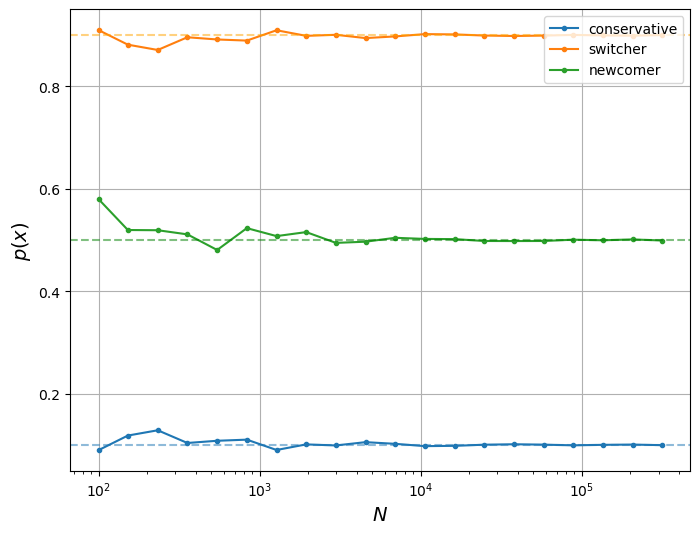

In [12]:
fig,ax = plt.subplots(figsize=(8, 6))
#xgrid = np.linspace(-10, 30, 1000)
plt.plot(arr_n, conservative_tallies,marker='.',label='conservative')
plt.plot(arr_n, switcher_tallies,marker='.',label='switcher')
plt.plot(arr_n, newcomer_tallies,marker='.',label='newcomer')

ax.axhline(1/n_doors, 0, 5000, linestyle='--', alpha=0.5)
ax.axhline((p+1)/n_doors, 0, 5000, linestyle='--', color='orange', alpha=0.5)
ax.axhline(1/(n_doors-p), 0, 5000, linestyle='--', color='green', alpha=0.5)

ax.set_xscale('log')
ax.set_ylabel('$p(x)$',fontsize=14)
ax.legend(loc='upper right')

ax.set_xlabel('$N$',fontsize=14)

plt.grid()

plt.show()

In [13]:
N = 10000
n_doors = 20
p = 8
d0 = int((random.random())*(n_doors))

doors = [1]
for i in range(n_doors-1):
    doors.append(0)



conservative_tallies = []
switcher_tallies = []
newcomer_tallies = []

arr_p = np.arange(1,n_doors-1)

for p in arr_p:
    conservative_tally = 0
    switcher_tally = 0
    newcomer_tally = 0
    
    
    for j in range(N):
        doors = [1]
        for i in range(n_doors-1): doors.append(0)
    
        #player selects a door
        random.seed(time.time())
        d0 = int(((random.random())*(n_doors)))
    
        result_conservative = doors[d0]
        #print(result_conservative)
            
        eligible_ind = []
        
        if d0 in range(1,n_doors):
            for i in (range(1,n_doors)): 
                if i != d0: eligible_ind.append(i)
        else: eligible_ind = range(1,n_doors)            
        
        goat_ind = random.sample(eligible_ind,p)
        doors2 = doors
        for i in goat_ind: doors2[i] = x
        
        surviving_minus_first_choice_ind = []
        for i in range(0,n_doors):
            if ((i not in np.array(goat_ind)) & (i!=d0)): surviving_minus_first_choice_ind.append(i)
                
        result_switcher = doors2[random.choice(surviving_minus_first_choice_ind)]
    
        surviving_ind = []
        for i in range(0,n_doors):
            if doors2[i]!=x: surviving_ind.append(i)
        result_newcomer = doors2[random.choice(surviving_ind)]
    
        conservative_tally+=result_conservative
        switcher_tally+=result_switcher
        newcomer_tally+=result_newcomer
    
    conservative_tallies.append(conservative_tally/N)
    switcher_tallies.append(switcher_tally/N)
    newcomer_tallies.append(newcomer_tally/N)

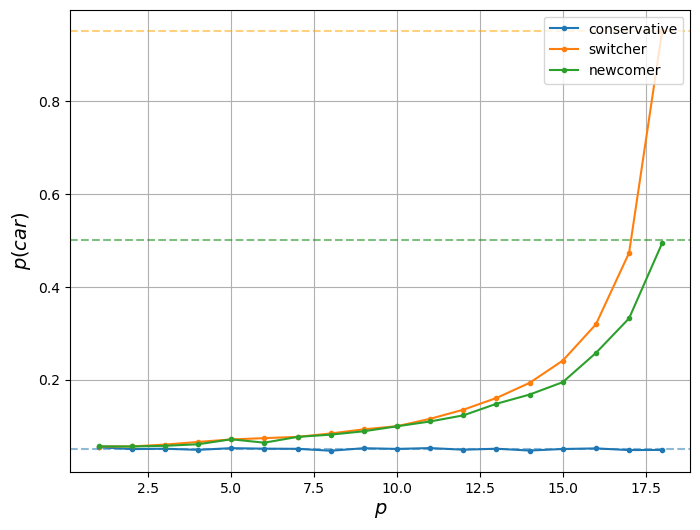

In [14]:
fig,ax = plt.subplots(figsize=(8, 6))
#xgrid = np.linspace(-10, 30, 1000)
plt.plot(arr_p, conservative_tallies,marker='.',label='conservative')
plt.plot(arr_p, switcher_tallies,marker='.',label='switcher')
plt.plot(arr_p, newcomer_tallies,marker='.',label='newcomer')

ax.axhline(1/n_doors, 0, 5000, linestyle='--', alpha=0.5)
ax.axhline((p+1)/n_doors, 0, 5000, linestyle='--', color='orange', alpha=0.5)
ax.axhline(1/(n_doors-p), 0, 5000, linestyle='--', color='green', alpha=0.5)

#ax.set_xscale('log')
ax.set_ylabel('$p(car)$',fontsize=14)
ax.legend(loc='upper right')

ax.set_xlabel('$p$',fontsize=14)

plt.grid()

plt.show()

In [ ]:
# pdf of log

In [17]:
from scipy.stats import uniform
unif = uniform(0.1,10)
x = unif.rvs(10000)
y = np.log10(x)

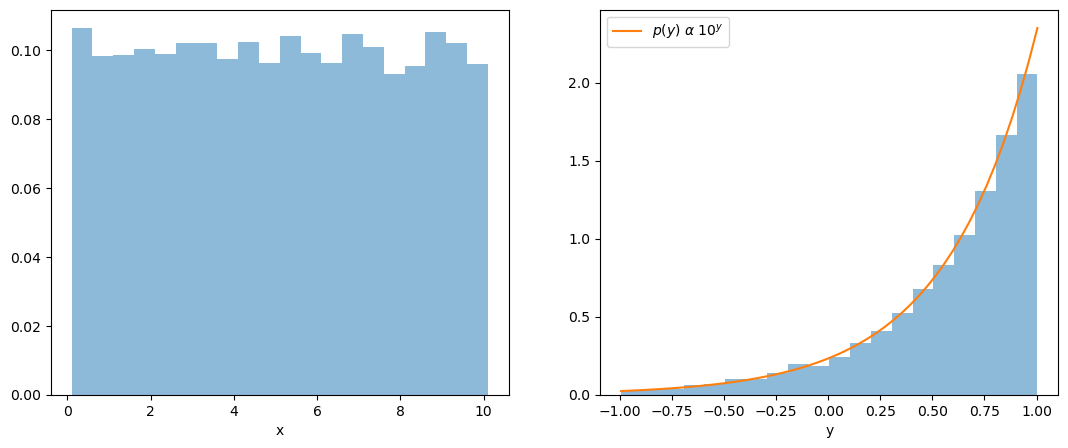

In [30]:
fig, ax = plt.subplots(1,2,figsize=(13,5))
ax[0].hist(x,20,density=True,alpha=0.5)
ax[0].set_xlabel('x')

ax[1].hist(y,20,density=True,alpha=0.5)
y_grid = np.linspace(min(y),max(y))
ax[1].plot(y_grid,10**y_grid*np.log(10)/(10-0.1),label=r'$p(y)$ $\alpha$ $10^y$')
ax[1].set_xlabel('y')
ax[1].legend()

In [32]:
print('means: %.3f %.3f' % (np.log10(np.mean(x)), np.mean(y)))
print('medians: %.3f %.3f' % (np.log10(np.median(x)), np.median(y)))

means: 0.706 0.586
medians: 0.706 0.706
